<a href="https://colab.research.google.com/github/Pratikshapawar-star/python-internship-practice-code/blob/main/Day11_Hierachical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv('/content/environmental_socioeconomic.csv')

In [ ]:
data.head()

,co2_emissions,waste_production,gdp,population
0,218.543053,436.276737,39199.932440,6.417631e+07
1,477.821438,399.620887,17380.479824,4.646995e+07
2,379.397274,258.538521,23865.587775,9.648535e+07
3,319.396318,646.540003,36531.225474,2.267887e+07
4,120.208388,528.961744,29283.573781,5.919779e+07


In [ ]:
data.shape

(10000, 4)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
print(pd.DataFrame(data_scaled,columns=data.columns).head())

   co2_emissions  waste_production       gdp  population
0      -0.415900         -0.452465  0.801884    0.482494
1       1.587377         -0.593258 -1.100359   -0.136414
2       0.826917         -1.135149 -0.534981    1.611824
3       0.363328          0.355146  0.569224   -0.968007
4      -1.175669         -0.096466 -0.062635    0.308475


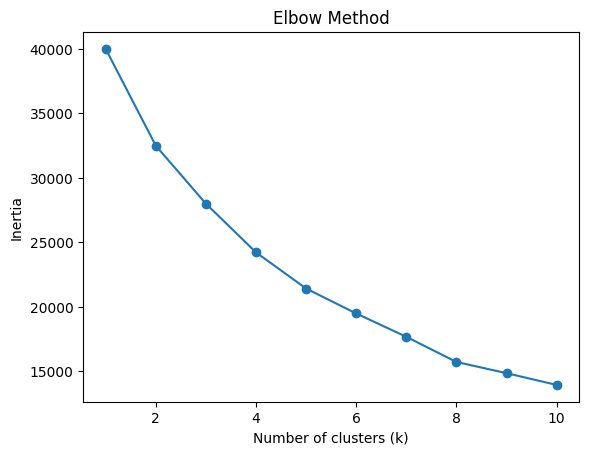

In [ ]:
inertia=[]
k_range = range(1,11)

for k in k_range:
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(data_scaled)
  inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker="o")
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()


In [ ]:
k=5
kmeans=KMeans(n_clusters=k, random_state=42)
data['cluster']= kmeans.fit_predict(data_scaled)

print(data.head())

   co2_emissions  waste_production           gdp    population  cluster
0     218.543053        436.276737  39199.932440  6.417631e+07        3
1     477.821438        399.620887  17380.479824  4.646995e+07        2
2     379.397274        258.538521  23865.587775  9.648535e+07        2
3     319.396318        646.540003  36531.225474  2.267887e+07        4
4     120.208388        528.961744  29283.573781  5.919779e+07        3


In [ ]:
sil_score = silhouette_score(data_scaled, data['cluster'])
print('Silhouette Score: ', sil_score)

Silhouette Score:  0.1947813398021011


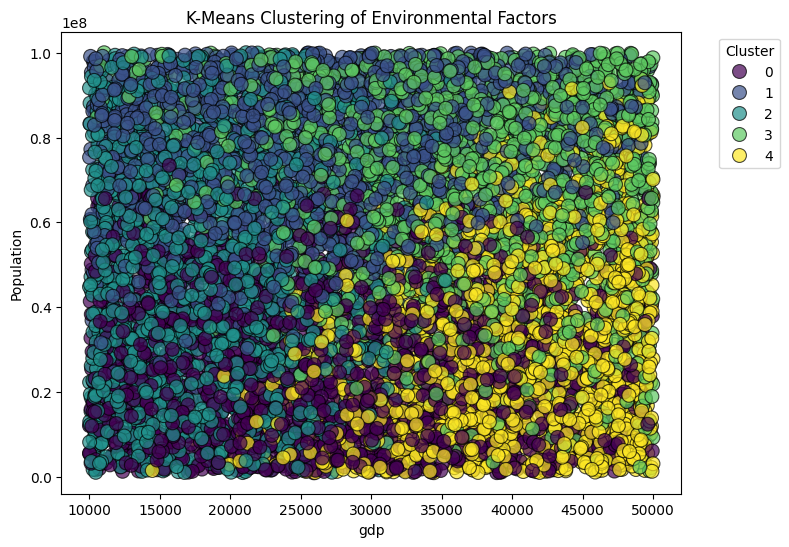

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='gdp', y='population', hue='cluster', data=data, palette='viridis',s=100,alpha=0.7,edgecolor='k')

plt.title('K-Means Clustering of Environmental Factors')
plt.xlabel('gdp')
plt.ylabel('Population')
plt.legend(title='Cluster',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

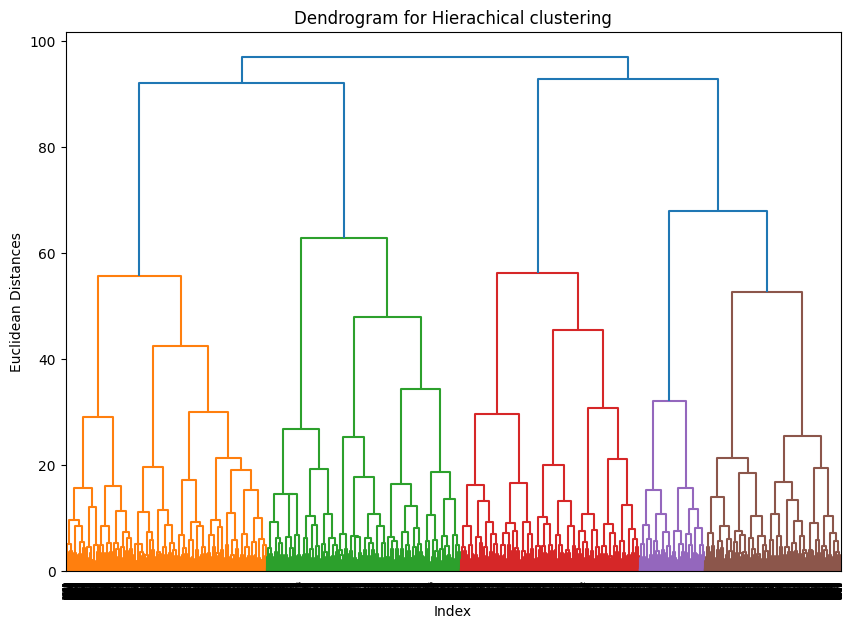

In [ ]:
# create a dendrogram
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(10,7))
dendrogram = sch.dendrogram(sch.linkage(data_scaled, method='ward'))
plt.title('Dendrogram for Hierachical clustering')
plt.xlabel('Index')
plt.ylabel('Euclidean Distances')
plt.show()



In [ ]:
hierachical_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
data['cluster']= hierachical_clustering.fit_predict(data_scaled)

In [ ]:
print(data.head())

   co2_emissions  waste_production           gdp    population  cluster
0     218.543053        436.276737  39199.932440  6.417631e+07        3
1     477.821438        399.620887  17380.479824  4.646995e+07        2
2     379.397274        258.538521  23865.587775  9.648535e+07        2
3     319.396318        646.540003  36531.225474  2.267887e+07        1
4     120.208388        528.961744  29283.573781  5.919779e+07        1


In [ ]:
sil_score = silhouette_score(data_scaled, data['cluster'])
print('Silhouette Score: ', sil_score)

Silhouette Score:  0.13124908918954956


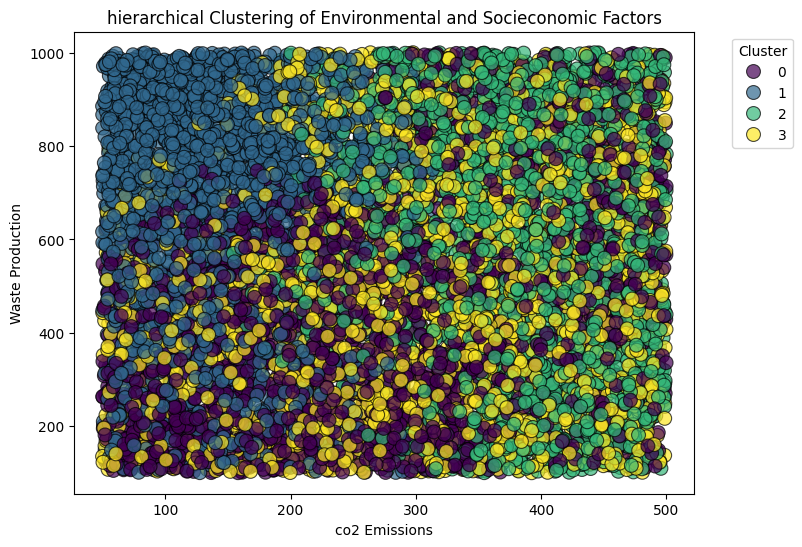

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='co2_emissions', y='waste_production', hue='cluster', data=data, palette='viridis',s=100,alpha=0.7,edgecolor='k')

plt.title('hierarchical Clustering of Environmental and Socieconomic Factors')
plt.xlabel('co2 Emissions')
plt.ylabel('Waste Production')
plt.legend(title='Cluster',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
x=data.drop('cluster',axis=1)
y=data['cluster']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x, y,test_size=0.2,random_state=42)

In [ ]:
model1=LogisticRegression()
model1.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred1=model1.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred1)

0.526